In [1]:
# Introduction

#........Statement The Problem.........

# Hepatitis C is a liver infection caused by Hepatitis C virus.
# For more than half of the people who become infected with the HPC virus,
# It becomes a long-term, chronic infection which can result in serious,
# even, life-threatening health problems like Cirrhosis and liver cancer.
# Hepatitis C is spread through contact with blood from an infected
# person. The best way to prevent Hepatitis C is by avoiding
# behaviours that can spread the disease.

# This project aims to create a model to predict if patients
# will be infected with Hepatitis C, based on their demographics
# and regular test results.

# The dataset contains data from Puerto Rican Patients who have been suspected 
# of having Hepatitis C based on their regular laboratory results, and 
# having taken antibody (Ab) or RNA test to confirm it.

In [2]:
# Load the library that is used to manipulate dataframes with the alias pd
import pandas as pd
from pandas import read_csv
from pandas import set_option
from pandas import to_numeric
from pandas.plotting import scatter_matrix

# Load the library that is used to manipulate arrays with the alias np
import numpy as np


# Load dataset and store it in the variable dataset
dataset = pd.read_csv("Hepatitis C.csv")



In [3]:
# Print the shape of the dataset
set_option('display.max_rows',500)
print(dataset.dtypes)
print(dataset.shape)


# Print  the summary description of the dataset
set_option('precision', 3)
print(dataset.describe())

# Print the first 10 lines of the dataset  
set_option('display.width',100)
print(dataset.head(10))




age-group                    float64
lab_zip                        int64
person_zip                     int64
13457-7_LDL                  float64
14957-5_Albumin              float64
1751-7_Albumin               float64
1975-2_Bilirubin             float64
2160-0_Creatinine (blood)    float64
2345-7_Fasting glucose       float64
3016-3_TSH                   float64
3024-7_Free T4               float64
3026-2_T4                    float64
3053-6_T3                    float64
4548-4_A1c                   float64
6690-2_WBC                   float64
6768-6_ALP                   float64
718-7_Hgb                    float64
789-8_RBC                    float64
88294-4_egfr-2               float64
gender_M                       int64
Hepatitis C                    int64
dtype: object
(1140, 21)
       age-group   lab_zip  person_zip  13457-7_LDL  14957-5_Albumin  \
count   1140.000  1140.000    1140.000     1140.000         1140.000   
mean      43.054   574.446     782.256      104.301   

In [4]:
'''
Using the functions groupby and size, 
determine how many patients have been  
diagnosed with Hepatitis C and how many are control cases.
'''
# Class Distribution of the Target Variable (Hepatitis C)
print(dataset.groupby('Hepatitis C').size())

Hepatitis C
0    918
1    222
dtype: int64


# Data Visualization

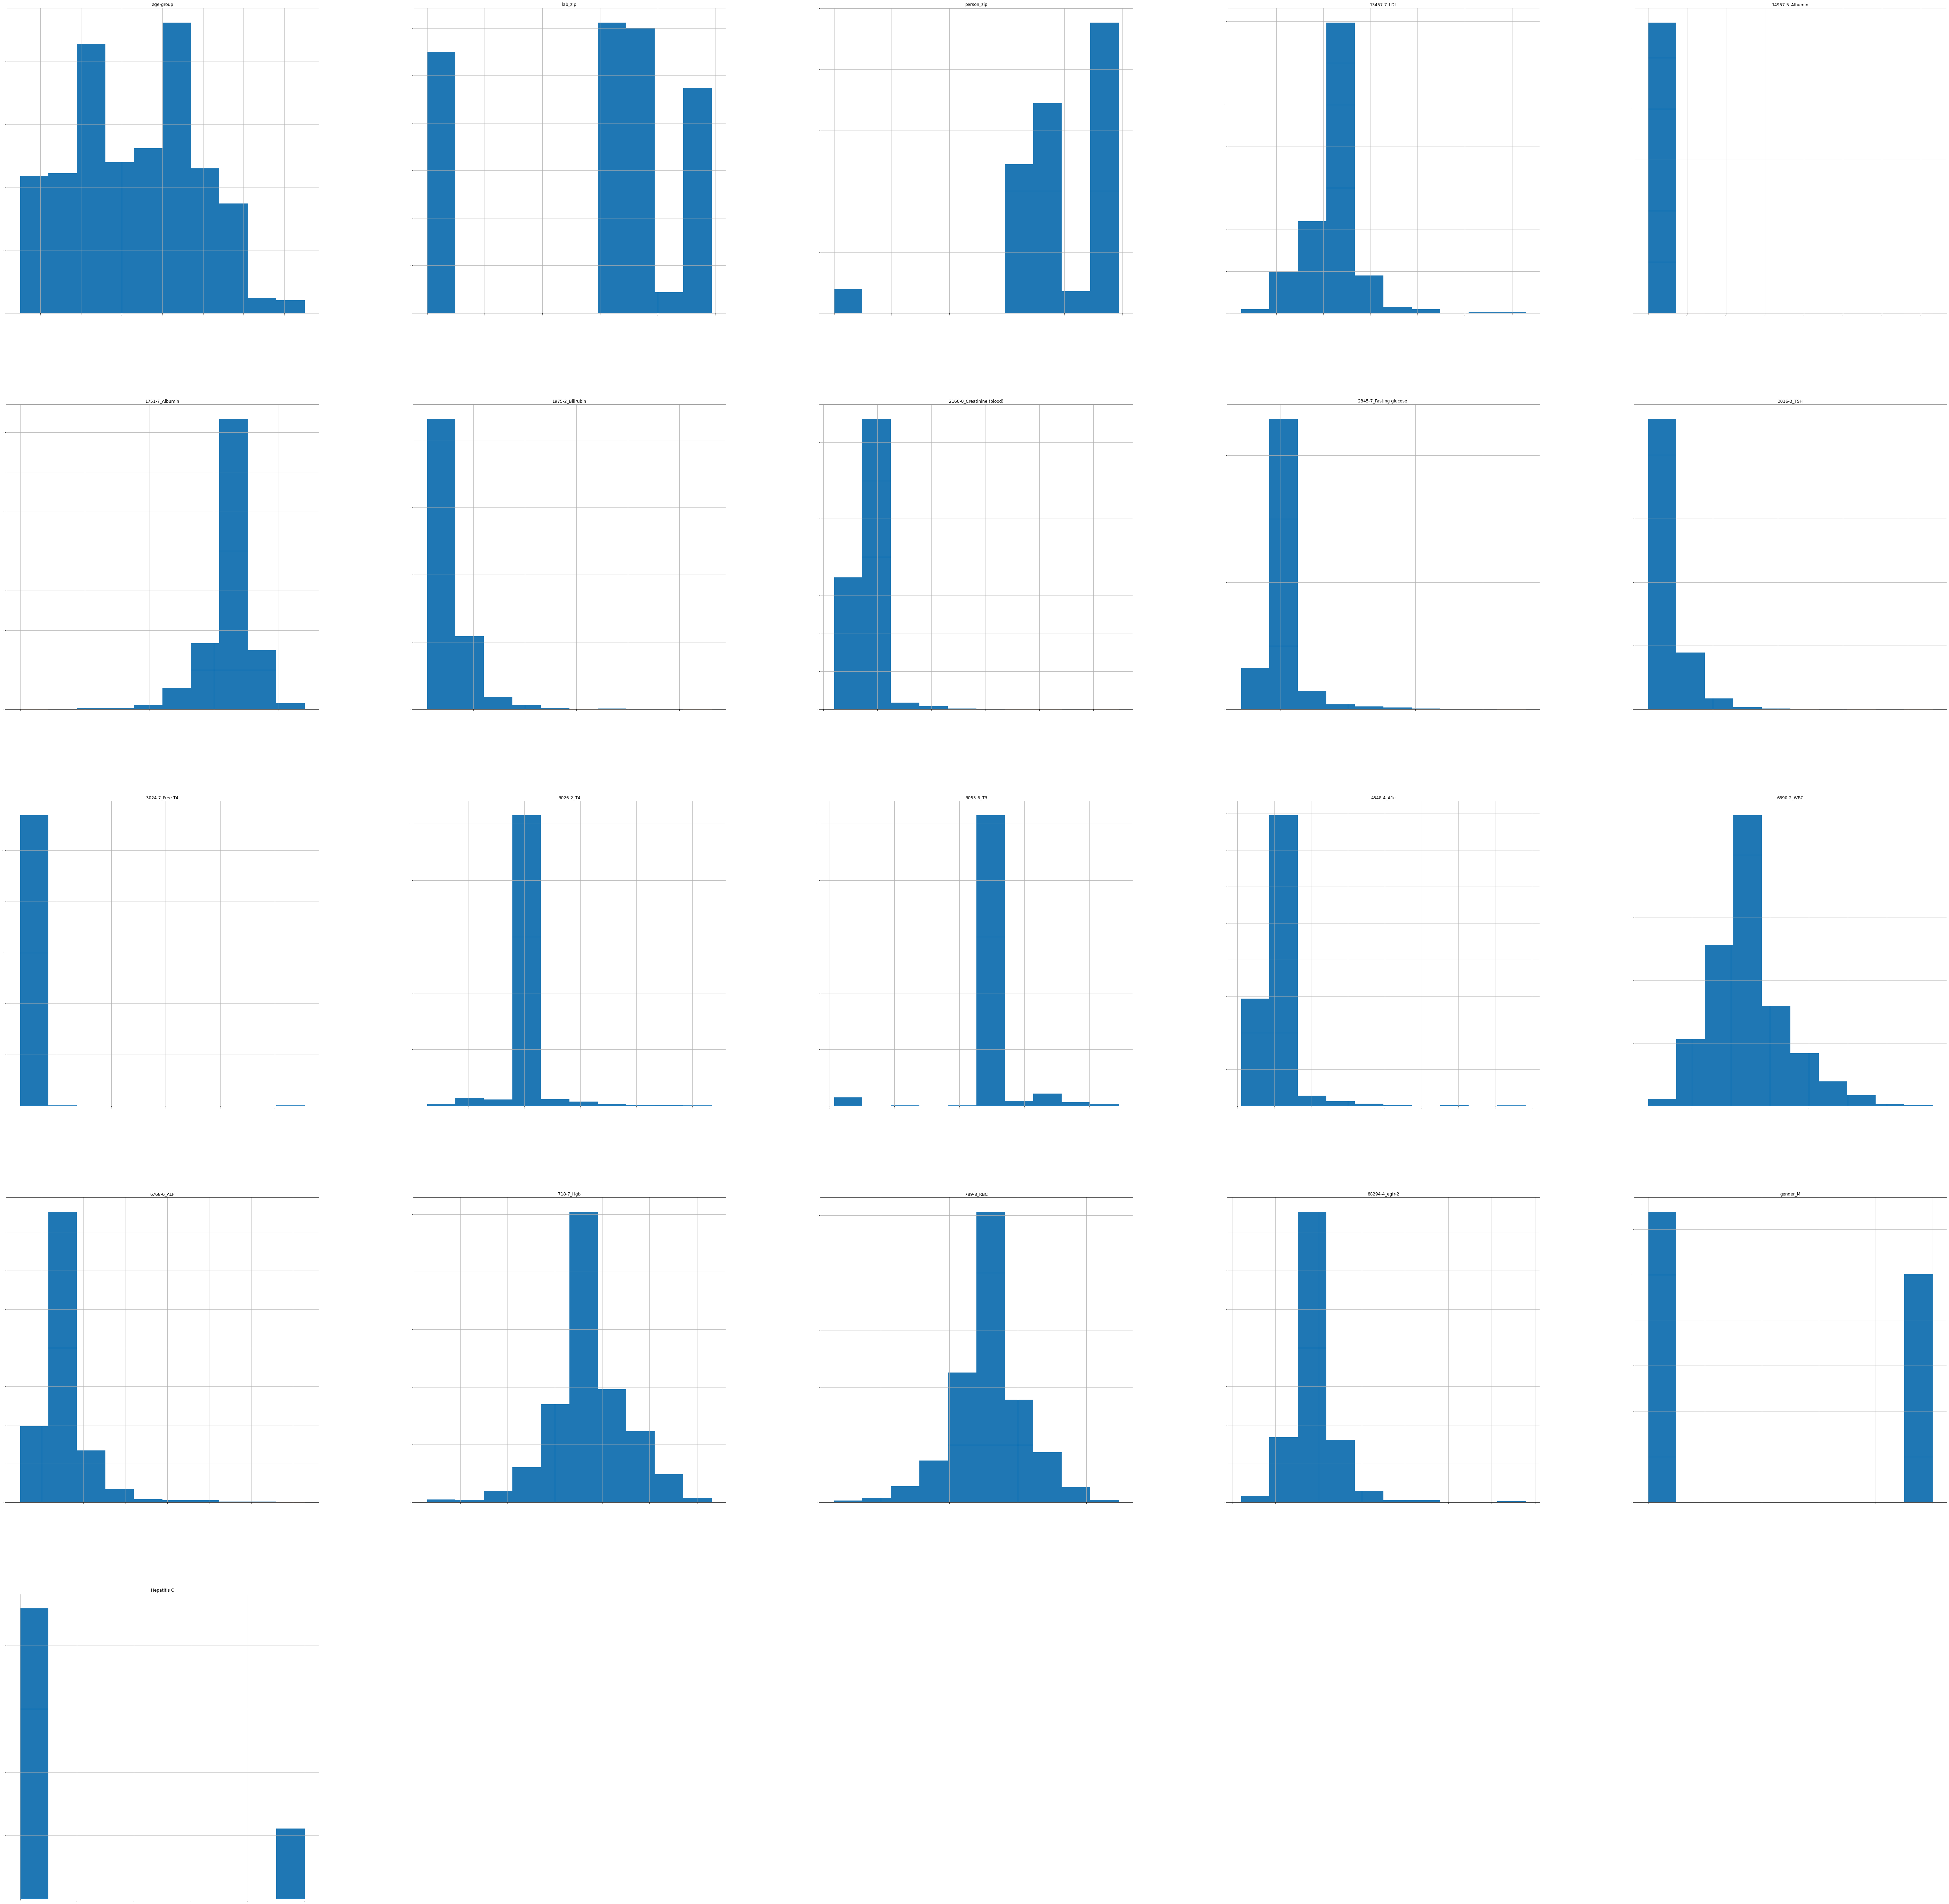

In [6]:
# Import the pyplot fuction from the matplotlib library 
import matplotlib
from matplotlib import pyplot


# Plot the histogram of the data using the hist function
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1)


# Display the plot using the show function
pyplot.rcParams["figure.figsize"] = (200,200)
pyplot.show()

In [7]:
# Plot the correlation matrix of the data

column=dataset.columns
fig = pyplot.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(dataset.corr('pearson'), vmin=-1, vmax=1, interpolation='none')
ax.set_xticks(np.arange(len(column)))
ax.set_yticks(np.arange(len(column)))
ax.set_xticklabels(column)
ax.set_yticklabels(column)
fig.colorbar(cax)
pyplot.show()


# Data Preparation

In [12]:


# Using the values function, convert the dataset into an array and store it into a variable
array = dataset.values

# Separate the target variable from the rest of the array using positional  indexing
X = array[:,0:20]
Y = array[:,20]

# Import the train_test_split from  sklearn.model_selection
from sklearn.model_selection import train_test_split

# Using the function train_test_split split-out 20% validation and 80% training dataset 
validate_size = 0.2
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validate_size, random_state=seed)



# Model Building


In [9]:
# Import the  LogisticRegression function from sklearn.linear_model
from sklearn.linear_model import LogisticRegression

# Import the DecisionTreeClassifier function from sklearn.tree
from sklearn.tree import DecisionTreeClassifier

# Import the KNeighborsClassifier function from sklearn.neighbors
from sklearn.neighbors import KNeighborsClassifier

# Import the LinearDiscriminantAnalysis function from sklearn.discriminant_analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Import the GaussianNB function from sklearn.naive_bayes
from sklearn.naive_bayes import GaussianNB

# Import the SVC function from sklearn.svm 
from sklearn.svm import SVC






In [10]:
# Create an empty list called models
models = []

# Using the append function, add an alias for the model and the  function to the list, 
# using "liblinear" as the solver.
# This one has been done for you.
models.append(('LR', LogisticRegression(solver='liblinear')))


# Using the append function, add an alias for the Linear Discriminant Analysis model and the 
# LinearDiscriminantAnalysis function to the list.
models.append(('LDA', LinearDiscriminantAnalysis()))

# Using the append function, add an alias for the K Neighbors Classifier model and the 
# KNeighborsClassifier function to the list.
models.append(('KNN', KNeighborsClassifier()))

# Using the append function, add an alias for the Decision Tree Classifier model and the 
# DecisionTreeClassifier function to the list.
models.append(('CART', DecisionTreeClassifier()))

# Using the append function, add an alias for the Gaussian Naive Bayes model and the 
# GaussianNB function to the list.
models.append(('NB', GaussianNB()))

# Using the append function, add an alias for the Support Vector Classifier model and the 
# SVC function to the list,using 'auto' as the value for the gamma parameter.
models.append(('SVM', SVC(gamma='auto')))

# Create an empty list called results
results = []

# Create an empty list called names
names = []




# Model Testing

In [16]:
# Now you will create a for loop to test the different models
# Import cross_val_score from sklearn.model_selection
from sklearn.model_selection import cross_val_score

# Create a for loop that iterates over two variables called name and model
for name, model in models:
    cv_results = cross_val_score(model, X_train,Y_train, cv=10, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Create an instance of cross_val_score with the following parameters:
# model, X_train, Y_train, cv=10, scoring="accuracy" and store the resutls as
# a variable called cv_results


# Append cv_results  to the previously created empty list called results 


# Append name to the previously created empty list called names


# print the name and the mean of cv_results using the fuction mean




LR: 0.821285 (0.014594)
LDA: 0.825645 (0.013550)
KNN: 0.858481 (0.038089)
CART: 0.827819 (0.027058)
NB: 0.700788 (0.072889)
SVM: 0.822384 (0.019314)


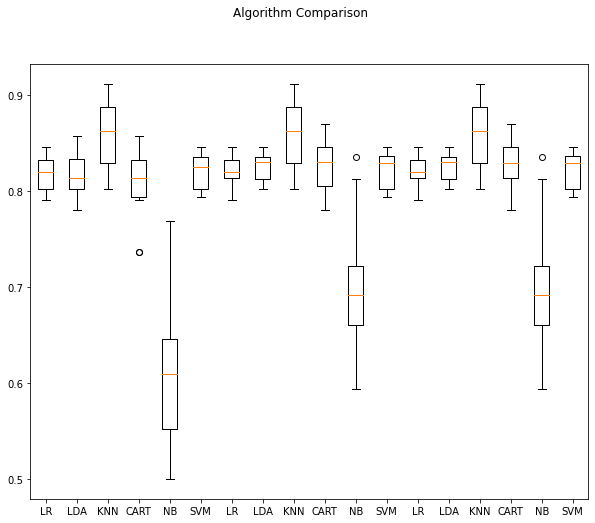

In [19]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.rcParams["figure.figsize"] = (10,12)
pyplot.show()


# Data standarization 
#### In this section you will reuse the varibles that were previewsly created but the data will be scaled 


In [20]:
# Import StandardScaler from sklearn.preprocessing 
from sklearn.preprocessing import StandardScaler

# Create an instance of  StandardScaler and store it into a variable called scaler
scaler = StandardScaler()

# Fit the training data to the scaler by employing the fit function 
scaler.fit(X_train)

# Transform the training data to the scaler by employing the transform function and store it into a variable called
# X_scaled
X_scaled = scaler.transform(X_train)



In [21]:
# Now you will create a for loop to test the different models with the scaled data
# Create an empty list called results
results = []

# Create an empty list called names
names = []

# Create a for loop that iterates over two variables called name and model
for name, model in models:
    cv_results = cross_val_score(model, X_scaled,Y_train, cv=10, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Create an instance of cross_val_score with the following parameters:
# model, X_scaled, Y_train, cv=10, scoring="accuracy" and store the resutls as
# a variable called cv_results


# Append cv_results  to the previously created empty list called results 


# Append name to the previously created empty list called names


# print the name and the mean of cv_results using the fuction mean




LR: 0.822348 (0.017031)
LDA: 0.825645 (0.013550)
KNN: 0.836550 (0.028316)
CART: 0.824546 (0.029151)
NB: 0.699689 (0.073585)
SVM: 0.864035 (0.026069)


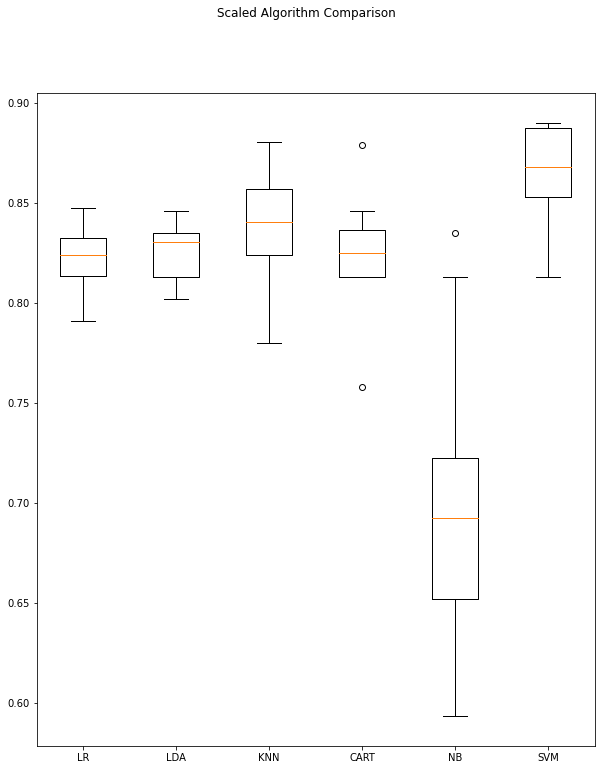

In [22]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.rcParams["figure.figsize"] = (10,12)
pyplot.show()


# Model Tunning

#### For this part, take a look a the results of the models and determine which group of models performed better, the scaled or regular. Out of the best group  select the two best performing models.

In [23]:
# If the best performing group of models were the scaled models, scale the validation data

# The scaled SVM followed by the scaled KNN performed better
scaler = StandardScaler().fit(X_validation)
rescaledX = scaler.transform(X_validation)

# If not, leave this space blank

# Create an instance of the Best performing model and store it into the variabe model
model = SVC(gamma='auto')

# Create a grid of parameters to test for the Best performing model
# In the jupyter for the Project example (check the PDF in this folder or the video for Topic 2) there are parameters available for each of the models
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
              'kernel': ['rbf']}

# Import KFold from sklearn.model_selection 
from sklearn.model_selection import KFold

# Create an instance of Kfold with the following parameters: n_splits=5, random_state=123, shuffle=True
# Store it into a variable called kfold
kfold = KFold(n_splits=10, random_state=123, shuffle=True)

# Import GridSearchCV from sklearn.model_selection 
from sklearn.model_selection import GridSearchCV

# Create an instance of GridSearchCV with the following parameters: estimator=model, param_grid=param_grid, 
# scoring="accuracy", cv=kfold. Store it into a variable called grid

grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring="accuracy", cv=kfold)

# Fit the validation data to the grid by employing the fit function, store it into a variable called grid_result 

grid_result = grid.fit(rescaledX, Y_validation)

# The following code will print the results of the grid search
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))





Best: 0.811067 using {'C': 1, 'kernel': 'rbf'}
0.798024 (0.096092) with: {'C': 0.1, 'kernel': 'rbf'}
0.811067 (0.081130) with: {'C': 1, 'kernel': 'rbf'}
0.784585 (0.099354) with: {'C': 10, 'kernel': 'rbf'}
0.762846 (0.096414) with: {'C': 100, 'kernel': 'rbf'}
0.741304 (0.117187) with: {'C': 1000, 'kernel': 'rbf'}


In [24]:
# Create an instance of the Best performing model and store it into the variabe model
model = KNeighborsClassifier()

# Create a grid of parameters to test for the Second Best performing model
# In the jupyter for the Project example (check the PDF in this folder or the video for Topic 2) there are parameters available for each of the models
k_range = list(range(1, 31)) # training 30 neighbours

param_grid = dict(n_neighbors=k_range)

# Create an instance of Kfold with the following parameters: n_splits=5, random_state=123, shuffle=True
# Store it into a variable called kfold
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, random_state=123, shuffle=True)

# Create an instance of GridSearchCV with the following parameters: estimator=model, param_grid=param_grid, 
# scoring="accuracy", cv=kfold. Store it into a variable called grid
grid = GridSearchCV(estimator=model,param_grid=param_grid, scoring="accuracy", cv=kfold)

# Fit the validation data to the grid by employing the fit function, store it into a variable called grid_result 
grid_result = grid.fit(rescaledX, Y_validation)

# The following code will print the results of the grid search

# The following code will print out the results of the grid search
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.824308 using {'n_neighbors': 27}
0.755534 (0.173603) with: {'n_neighbors': 1}
0.816008 (0.084323) with: {'n_neighbors': 2}
0.754348 (0.088638) with: {'n_neighbors': 3}
0.789526 (0.074636) with: {'n_neighbors': 4}
0.762648 (0.054800) with: {'n_neighbors': 5}
0.798024 (0.083669) with: {'n_neighbors': 6}
0.784783 (0.081064) with: {'n_neighbors': 7}
0.793676 (0.080923) with: {'n_neighbors': 8}
0.767194 (0.092404) with: {'n_neighbors': 9}
0.780632 (0.085054) with: {'n_neighbors': 10}
0.776087 (0.069861) with: {'n_neighbors': 11}
0.780830 (0.070209) with: {'n_neighbors': 12}
0.793676 (0.081571) with: {'n_neighbors': 13}
0.802569 (0.081323) with: {'n_neighbors': 14}
0.806917 (0.090124) with: {'n_neighbors': 15}
0.798221 (0.085646) with: {'n_neighbors': 16}
0.802174 (0.099870) with: {'n_neighbors': 17}
0.819763 (0.095795) with: {'n_neighbors': 18}
0.810870 (0.088911) with: {'n_neighbors': 19}
0.819763 (0.088892) with: {'n_neighbors': 20}
0.810870 (0.091012) with: {'n_neighbors': 21}
0.

# Saving the model

In [25]:
# If the best performing models after modeling was the scaled, scale the validation data
scaler = StandardScaler().fit(X_validation)
rescaledX = scaler.transform(X_validation)

# If not, leave this space blank


# Create an instance of the best performing model and store it into the variabe model
model = KNeighborsClassifier(n_neighbors=27)

# Fit the validation data to the model by employing the fit function
model.fit(rescaledX, Y_validation)

# Estimate accuracy on validation dataset by employing the transform function on model
rescaledValidationX = scaler.transform(X_validation)

# store it into a variable called predictions
predictions = model.predict(rescaledValidationX)

# Import accuracy_score from sklearn.metrics 
from sklearn.metrics import accuracy_score

# Import confusion_matrix from sklearn.metrics 
from sklearn.metrics import confusion_matrix

# Import classification_report from sklearn.metrics 
from sklearn.metrics import classification_report

# Inside a print statement, call the fuction accuracy_score, with the following parameters:
# Y_validation, predictions
print(accuracy_score(Y_validation, predictions))

# Inside a print statement, call the fuction confusion_matrix, with the following parameters:
# Y_validation, predictions
print(confusion_matrix(Y_validation, predictions))

# Inside a print statement, call the fuction classification_report, with the following parameters:
# Y_validation, predictions
print(classification_report(Y_validation, predictions))


0.8333333333333334
[[177   5]
 [ 33  13]]
              precision    recall  f1-score   support

         0.0       0.84      0.97      0.90       182
         1.0       0.72      0.28      0.41        46

    accuracy                           0.83       228
   macro avg       0.78      0.63      0.65       228
weighted avg       0.82      0.83      0.80       228

